In [15]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

version : default
seed : 1
mu : 1.0
x0 : 0.5
x_t0 : 0.0
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***


/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***


/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***


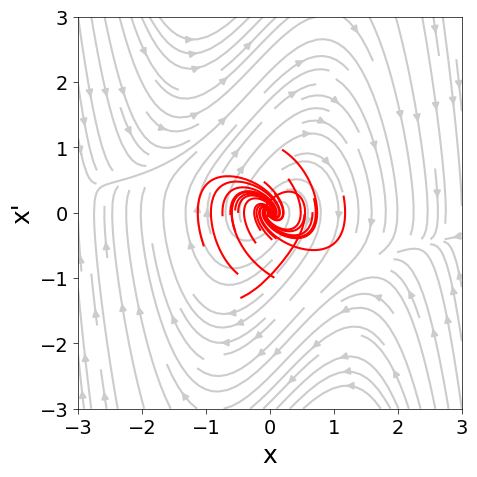

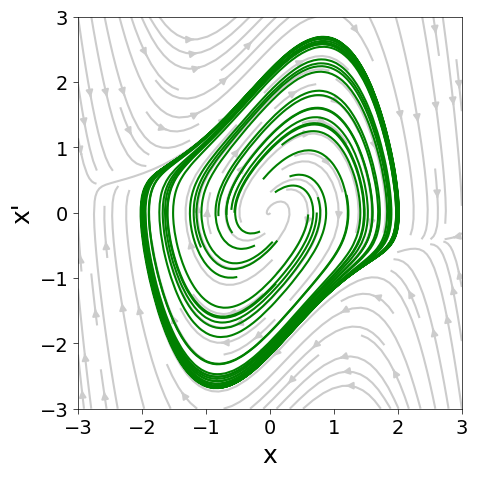

In [16]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 18,
                     'axes.labelsize': 18,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })


config = load_config('configs/default.yaml')
config["T"] = 15

base_dir = f"models/visualization_experiments_{str(config['T']).replace(".", "_")}_50000_new"


PINN = PhysicsInformedNN(config)

results_table = pd.read_csv(f"qualitative_results_new_50000.csv").sample(20)

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-3, 3, n_arrows)
x_t = np.linspace(-3, 3, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

plt.figure(figsize=(5, 5))

plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(results_table["path no reg"].iloc[i])
    t_line, x_true, x_t_true = PINN.data.reference()
    # get PINN prediction
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)

    color = 'green' if results_table["success no reg"].iloc[i] else "red"
    plt.plot(x_pred, x_t_pred, color=color)
    plt.xlabel("x")
    plt.ylabel("x\'")

plt.tight_layout()
plt.savefig("van_der_pol_no_reg.pdf", format="pdf")

plt.figure(figsize=(5, 5))
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)
for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(results_table["path reg"].iloc[i])
    t_line, x_true, x_t_true = PINN.data.reference()
    # get PINN prediction
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)
    color = 'green' if results_table["success reg"].iloc[i] else "red"
    plt.plot(x_pred, x_t_pred, color=color)
    plt.xlabel("x")
    plt.ylabel("x\'")
    # plt.ylabel("y", fontsize=18)
    # plt.yticks([])

# plt.show()
plt.tight_layout()
plt.savefig("van_der_pol_reg_derivative_unstable_fp.pdf", format="pdf")